In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv('pipeline_results_eval.csv', dtype={'id': str})
print(df.columns)

Index(['id', 'actor', 'pose', 'cam_pitch', 'gt_dist', 'gt_ang_sep', 'gt_d_yaw',
       'gt_d_pitch', 'gt_sw_x', 'gt_sw_y', 'gt_sw_z', 'gt_sc_x', 'gt_sc_y',
       'gt_sc_z', 'b3ad_dist', 'b3ad_ang_sep', 'b3ad_d_yaw', 'b3ad_d_pitch',
       'b3ad_sw_x', 'b3ad_sw_y', 'b3ad_sw_z', 'b3ad_sc_x', 'b3ad_sc_y',
       'b3ad_sc_z', 'b3sd_dist', 'b3sd_ang_sep', 'b3sd_d_yaw', 'b3sd_d_pitch',
       'b3sd_sw_x', 'b3sd_sw_y', 'b3sd_sw_z', 'b3sd_sc_x', 'b3sd_sc_y',
       'b3sd_sc_z', 'm3ad_dist', 'm3ad_ang_sep', 'm3ad_d_yaw', 'm3ad_d_pitch',
       'm3ad_sw_x', 'm3ad_sw_y', 'm3ad_sw_z', 'm3ad_sc_x', 'm3ad_sc_y',
       'm3ad_sc_z', 'm3sd_dist', 'm3sd_ang_sep', 'm3sd_d_yaw', 'm3sd_d_pitch',
       'm3sd_sw_x', 'm3sd_sw_y', 'm3sd_sw_z', 'm3sd_sc_x', 'm3sd_sc_y',
       'm3sd_sc_z', 'm3pa_dist', 'm3pa_ang_sep', 'm3pa_d_yaw', 'm3pa_d_pitch',
       'm3pa_sw_x', 'm3pa_sw_y', 'm3pa_sw_z', 'm3pa_sc_x', 'm3pa_sc_y',
       'm3pa_sc_z', 'm2as_dist', 'm2as_ang_sep', 'm2as_d_yaw', 'm2as_d_pitch',
       'm2as

In [26]:
models = ['b3ad', 'b3sd', 'm3ad', 'm3sd', 'm3pa', 'm2as', 'm2st']

### **Create New Metrics**

In [27]:
# Cosine Similarity Error

gt_sw = df[['gt_sw_x', 'gt_sw_y', 'gt_sw_z']].values
gt_norm = np.linalg.norm(gt_sw, axis=1)

for m in models:
    pred_sw = df[[f'{m}_sw_x', f'{m}_sw_y', f'{m}_sw_z']].values
    pred_norm = np.linalg.norm(pred_sw, axis=1)

    dot = np.sum(gt_sw * pred_sw, axis=1)
    cos_sim = dot / (gt_norm * pred_norm + 1e-8)

    cos_sim = np.clip(cos_sim, -1.0, 1.0)

    df[f'{m}_sw_cos_err'] = 1 - cos_sim

In [28]:
# 3D Euclidean Error

gt_scaled = gt_sw * df['gt_dist'].values[:, None]

for m in models:
    pred_sw = df[[f'{m}_sw_x', f'{m}_sw_y', f'{m}_sw_z']].values
    pred_scaled = pred_sw * df[f'{m}_dist'].values[:, None]

    diff = pred_scaled - gt_scaled
    err = np.linalg.norm(diff, axis=1)

    df[f'{m}_sw_scaled_err'] = err

In [29]:
# Normalized 3D Euclidean Error

for m in models:
    df[f'{m}_sw_scaled_err_norm'] = (
        df[f'{m}_sw_scaled_err'] / (df['gt_dist'] + 1e-8)
    )

In [30]:
# Distance / yaw / pitch errors

for m in models:
    df[f'{m}_dist_err'] = (df[f'{m}_dist'] - df['gt_dist']).abs()
    df[f'{m}_yaw_err'] = (df[f'{m}_d_yaw'] - df['gt_d_yaw']).abs()
    df[f'{m}_pitch_err'] = (df[f'{m}_d_pitch'] - df['gt_d_pitch']).abs()

### **Metric Per Pipeline**

In [31]:
def aggregate_metric(metric_suffix):
    return pd.Series({
        m: df[f'{m}_{metric_suffix}'].mean(skipna=True)
        for m in models
    })

def count_nans(metric_suffix):
    return pd.Series({
        m: df[f'{m}_{metric_suffix}'].isna().sum()
        for m in models
    })

In [32]:
cos_err = aggregate_metric('sw_cos_err')
dist_err = aggregate_metric('dist_err')
scaled_err = aggregate_metric('sw_scaled_err_norm')
yaw_err = aggregate_metric('yaw_err')
pitch_err = aggregate_metric('pitch_err')
nan_counts = count_nans('dist')

In [33]:
def plot_metric(series, title, ylabel):
    plt.figure(figsize=(8, 5))
    series.plot(kind='bar')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [34]:
highlight_map = {
    'Cosine Error': ['m3ad', 'm3sd', 'm2as'],
    'Distance Error': ['b3sd','m3sd', 'm2as'],
    'Normalized 3D Error': ['b3sd','m3sd', 'm2as'],
    'Yaw Error': ['m3ad', 'm3sd', 'm2as'],
    'Pitch Error': ['m2as'],
    'Failure Count': ['b3ad', 'b3sd'],
}

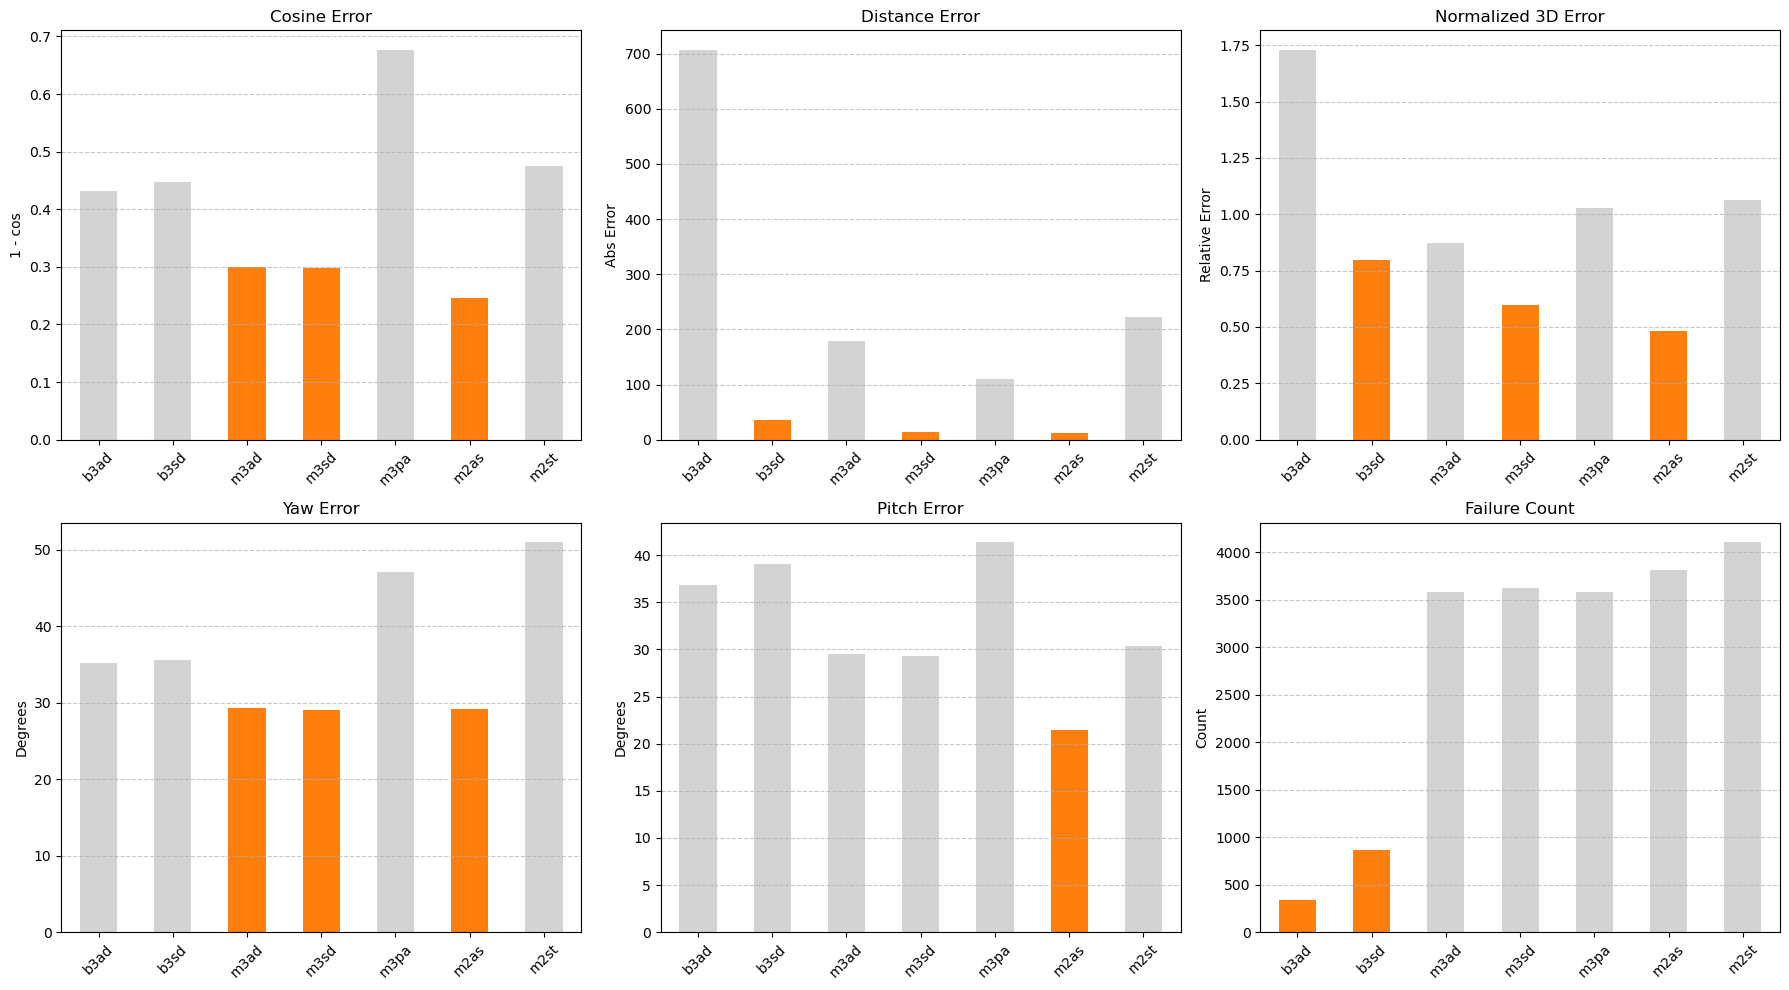

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    (cos_err, 'Cosine Error', '1 - cos'),
    (dist_err, 'Distance Error', 'Abs Error'),
    (scaled_err, 'Normalized 3D Error', 'Relative Error'),
    (yaw_err, 'Yaw Error', 'Degrees'),
    (pitch_err, 'Pitch Error', 'Degrees'),
    (nan_counts, 'Failure Count', 'Count')
]

default_color = 'lightgray'

for ax, (series, title, ylabel) in zip(axes.flatten(), plots):
    colors = [default_color] * len(series)

    if title in highlight_map:
        pipelines = highlight_map[title]
        for i, idx in enumerate(series.index):
            if idx in pipelines:
                colors[i] = 'tab:orange'

    series.plot(kind='bar', ax=ax, color=colors)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Metric Per Actor**

In [36]:
df['actor_clean'] = df['actor'].str.split('_').str[1]

In [37]:
def aggregate_metric_all_pipelines_per_actor(metric_suffix):
    cols = [f'{m}_{metric_suffix}' for m in models]
    return df.groupby('actor_clean')[cols].mean().mean(axis=1)

def count_nans_all_pipelines_per_actor(metric_suffix):
    cols = [f'{m}_{metric_suffix}' for m in models]
    return df.groupby('actor_clean')[cols].apply(lambda x: x.isna().sum().sum())

In [38]:
cos_err_actor = aggregate_metric_all_pipelines_per_actor('sw_cos_err')
dist_err_actor = aggregate_metric_all_pipelines_per_actor('dist_err')
scaled_err_actor = aggregate_metric_all_pipelines_per_actor('sw_scaled_err_norm')
yaw_err_actor = aggregate_metric_all_pipelines_per_actor('yaw_err')
pitch_err_actor = aggregate_metric_all_pipelines_per_actor('pitch_err')
nan_counts_actor = count_nans_all_pipelines_per_actor('dist_err')

In [39]:
highlight_map = {
    'Cosine Error': [],
    'Distance Error': ['Bernice', 'Koda', 'Sadhil'],
    'Normalized 3D Error': ['Bernice'],
    'Yaw Error': [],
    'Pitch Error': [],
    'Failure Count': []
}

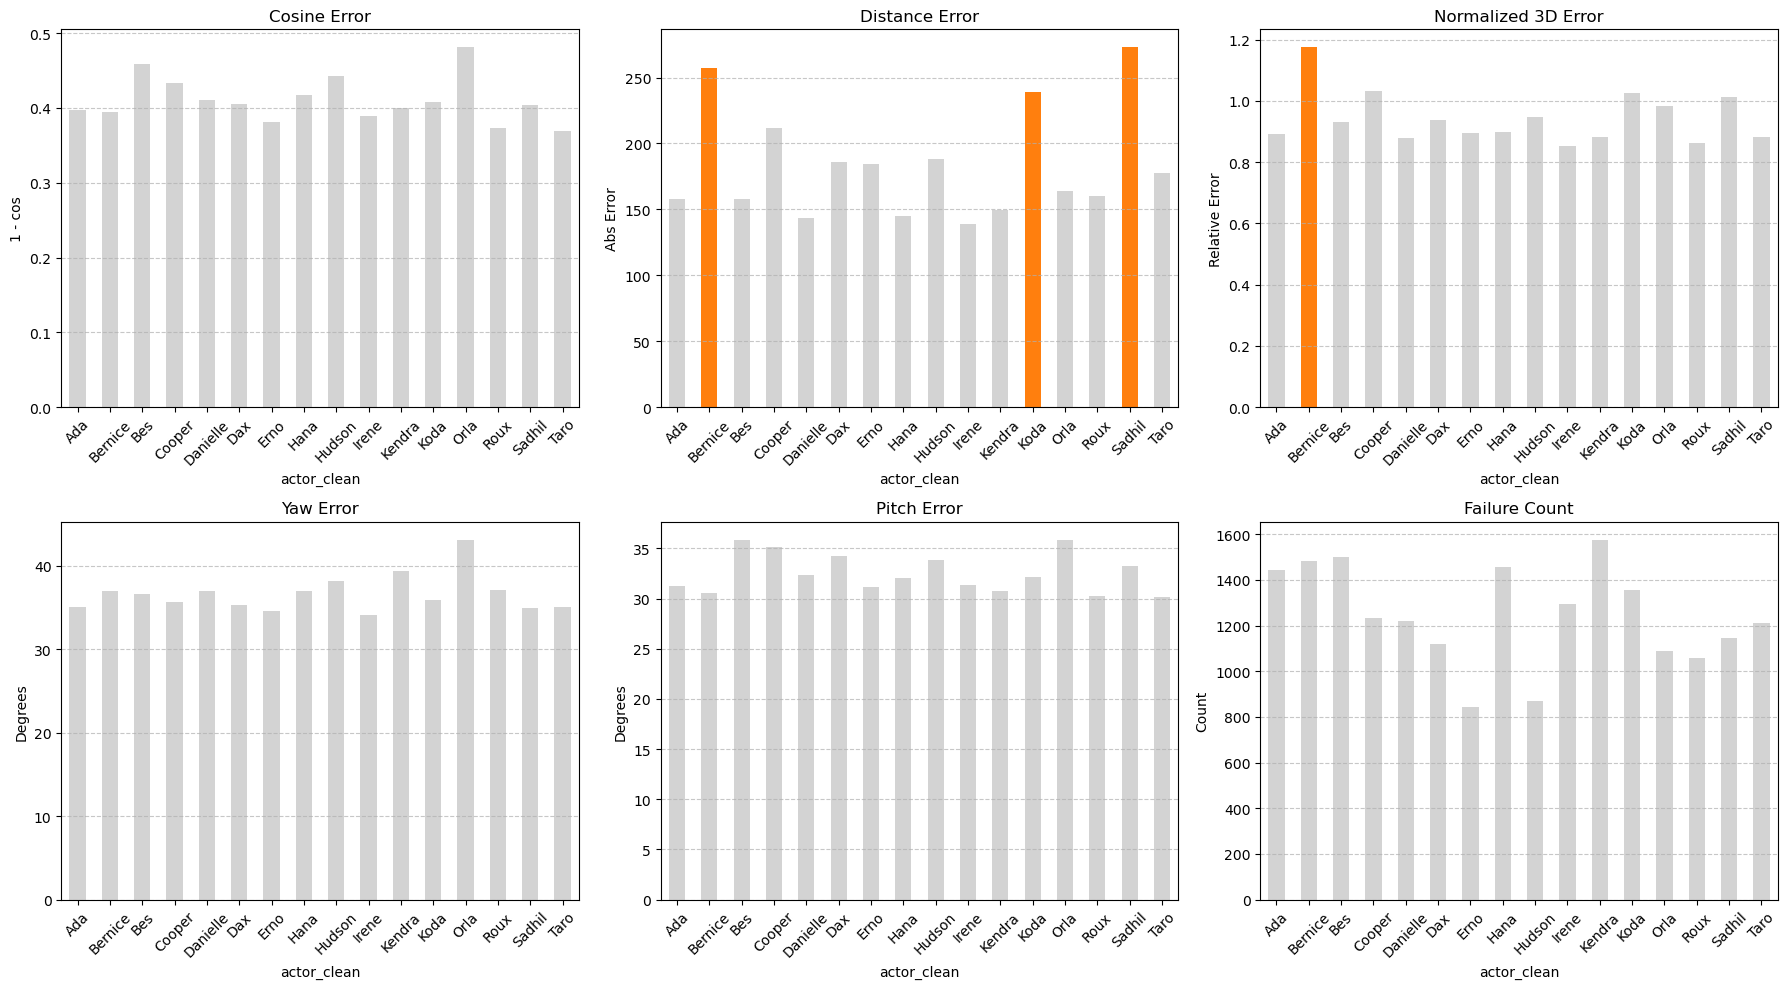

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    (cos_err_actor, 'Cosine Error', '1 - cos'),
    (dist_err_actor, 'Distance Error', 'Abs Error'),
    (scaled_err_actor, 'Normalized 3D Error', 'Relative Error'),
    (yaw_err_actor, 'Yaw Error', 'Degrees'),
    (pitch_err_actor, 'Pitch Error', 'Degrees'),
    (nan_counts_actor, 'Failure Count', 'Count')
]

default_color = 'lightgray'
highlight_color = 'tab:orange'

for ax, (series, title, ylabel) in zip(axes.flatten(), plots):
    colors = [default_color] * len(series)

    if title in highlight_map:
        highlighted_actors = highlight_map[title]

        for i, actor in enumerate(series.index):
            if actor in highlighted_actors:
                colors[i] = highlight_color

    series.plot(kind='bar', ax=ax, color=colors)

    ax.set_title(f'{title}')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### **Metric Per GT Distance**

In [41]:
bins = list(range(250, 1001, 50))
df["dist_bin"] = pd.cut(df["gt_dist"], bins=bins)

In [42]:
def row_mean_over_pipelines(metric_suffix):
    cols = [f'{m}_{metric_suffix}' for m in models]
    return df[cols].mean(axis=1)

In [43]:
df['cos_err'] = row_mean_over_pipelines('sw_cos_err')
df['dist_err'] = row_mean_over_pipelines('dist_err')
df['scaled_err'] = row_mean_over_pipelines('sw_scaled_err_norm')
df['yaw_err'] = row_mean_over_pipelines('yaw_err')
df['pitch_err'] = row_mean_over_pipelines('pitch_err')
df['nan_flag'] = df[[f'{m}_dist' for m in models]].isna().any(axis=1)

In [44]:
cos_by_dist = df.groupby('dist_bin')['cos_err'].mean()
dist_by_dist = df.groupby('dist_bin')['dist_err'].mean()
scaled_by_dist = df.groupby('dist_bin')['scaled_err'].mean()
yaw_by_dist = df.groupby('dist_bin')['yaw_err'].mean()
pitch_by_dist = df.groupby('dist_bin')['pitch_err'].mean()
nan_by_dist = df.groupby('dist_bin')['nan_flag'].mean()

C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_55852\4166187457.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cos_by_dist = df.groupby('dist_bin')['cos_err'].mean()
C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_55852\4166187457.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_by_dist = df.groupby('dist_bin')['dist_err'].mean()
C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_55852\4166187457.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the f

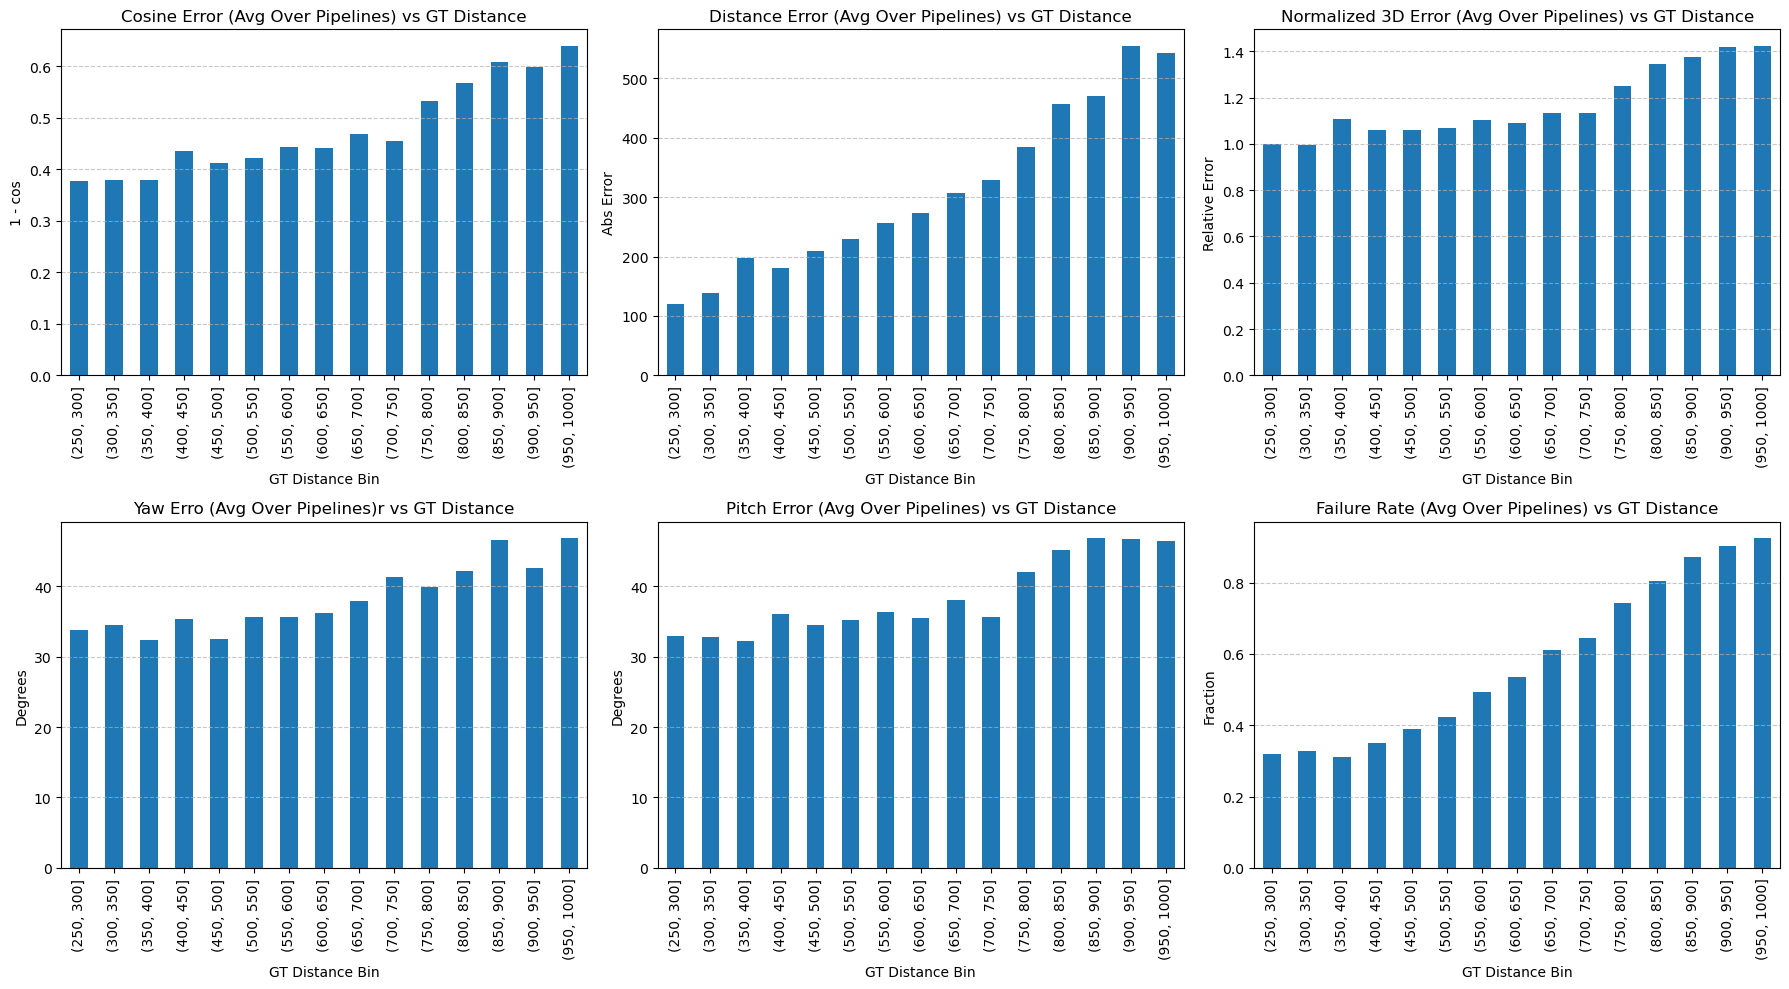

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plots = [
    (cos_by_dist, 'Cosine Error (Avg Over Pipelines) vs GT Distance', '1 - cos'),
    (dist_by_dist, 'Distance Error (Avg Over Pipelines) vs GT Distance', 'Abs Error'),
    (scaled_by_dist, 'Normalized 3D Error (Avg Over Pipelines) vs GT Distance', 'Relative Error'),
    (yaw_by_dist, 'Yaw Erro (Avg Over Pipelines)r vs GT Distance', 'Degrees'),
    (pitch_by_dist, 'Pitch Error (Avg Over Pipelines) vs GT Distance', 'Degrees'),
    (nan_by_dist, 'Failure Rate (Avg Over Pipelines) vs GT Distance', 'Fraction')
]

for ax, (series, title, ylabel) in zip(axes.flatten(), plots):
    series.plot(kind='bar', ax=ax, color='tab:blue')

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('GT Distance Bin')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [46]:
bin_specs = {
    "dist": {
        "col": "gt_dist",
        "bins": list(range(250, 1001, 50)),
        "label": "GT Distance"
    },
    "yaw": {
        "col": "gt_d_yaw",
        "bins": list(range(-135, 156, 10)),
        "label": "GT Yaw"
    },
    "pitch": {
        "col": "gt_d_pitch",
        "bins": list(range(-90, 86, 5)),
        "label": "GT Pitch"
    },
    "pose": {
        "col": "pose",
        "bins": np.arange(df["pose"].min(), df["pose"].max() + 2),
        "label": "Pose (int)"
    },
    "cam_pitch": {
        "col": "cam_pitch",
        "bins": list(range(-90, 1, 5)),
        "label": "Camera Pitch"
    }
}

In [47]:
for k, spec in bin_specs.items():
    if k == "pose":
        df[f"{k}_bin"] = pd.cut(
            df[spec["col"]],
            bins=spec["bins"],
            labels=False
        )
    else:
        df[f"{k}_bin"] = pd.cut(
            df[spec["col"]],
            bins=spec["bins"]
        )

In [48]:
def row_mean_over_pipelines(metric_suffix):
    cols = [f'{m}_{metric_suffix}' for m in models]
    return df[cols].mean(axis=1)


df['cos_err'] = row_mean_over_pipelines('sw_cos_err')
df['dist_err'] = row_mean_over_pipelines('dist_err')
df['scaled_err'] = row_mean_over_pipelines('sw_scaled_err_norm')
df['yaw_err'] = row_mean_over_pipelines('yaw_err')
df['pitch_err'] = row_mean_over_pipelines('pitch_err')

df['nan_flag'] = df[[f'{m}_dist' for m in models]].isna().any(axis=1)

In [49]:
metrics = {
    "cos_err": "Cosine Error",
    "dist_err": "Distance Error",
    "scaled_err": "Normalized 3D Error",
    "yaw_err": "Yaw Error",
    "pitch_err": "Pitch Error",
    "nan_flag": "Failure Rate"
}

def compute_grouped(df, bin_col):
    return {m: df.groupby(bin_col)[m].mean() for m in metrics}

In [50]:
def plot_binned_results(df, bin_key):
    bin_col = f"{bin_key}_bin"
    grouped = compute_grouped(df, bin_col)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    plot_specs = [
        ("cos_err", "Cosine Error (Averaged Over Pipelines)", "1 - cos"),
        ("dist_err", "Distance Error (Averaged Over Pipelines)", "Abs Error"),
        ("scaled_err", "Normalized 3D Error (Averaged Over Pipelines)", "Relative Error"),
        ("yaw_err", "Yaw Error (Averaged Over Pipelines)", "Degrees"),
        ("pitch_err", "Pitch Error (Averaged Over Pipelines)", "Degrees"),
        ("nan_flag", "Failure Rate (Averaged Over Pipelines)", "Fraction")
    ]

    for ax, (metric, title, ylabel) in zip(axes.flatten(), plot_specs):
        grouped[metric].plot(kind='bar', ax=ax, color='tab:blue')

        ax.set_title(f"{title} vs {bin_specs[bin_key]['label']}")
        ax.set_xlabel(bin_specs[bin_key]['label'] + " Bin")
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        if bin_key == "pose":
            ax.tick_params(axis='x', labelbottom=False)

    plt.tight_layout()
    plt.show()

C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_55852\1534718949.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {m: df.groupby(bin_col)[m].mean() for m in metrics}


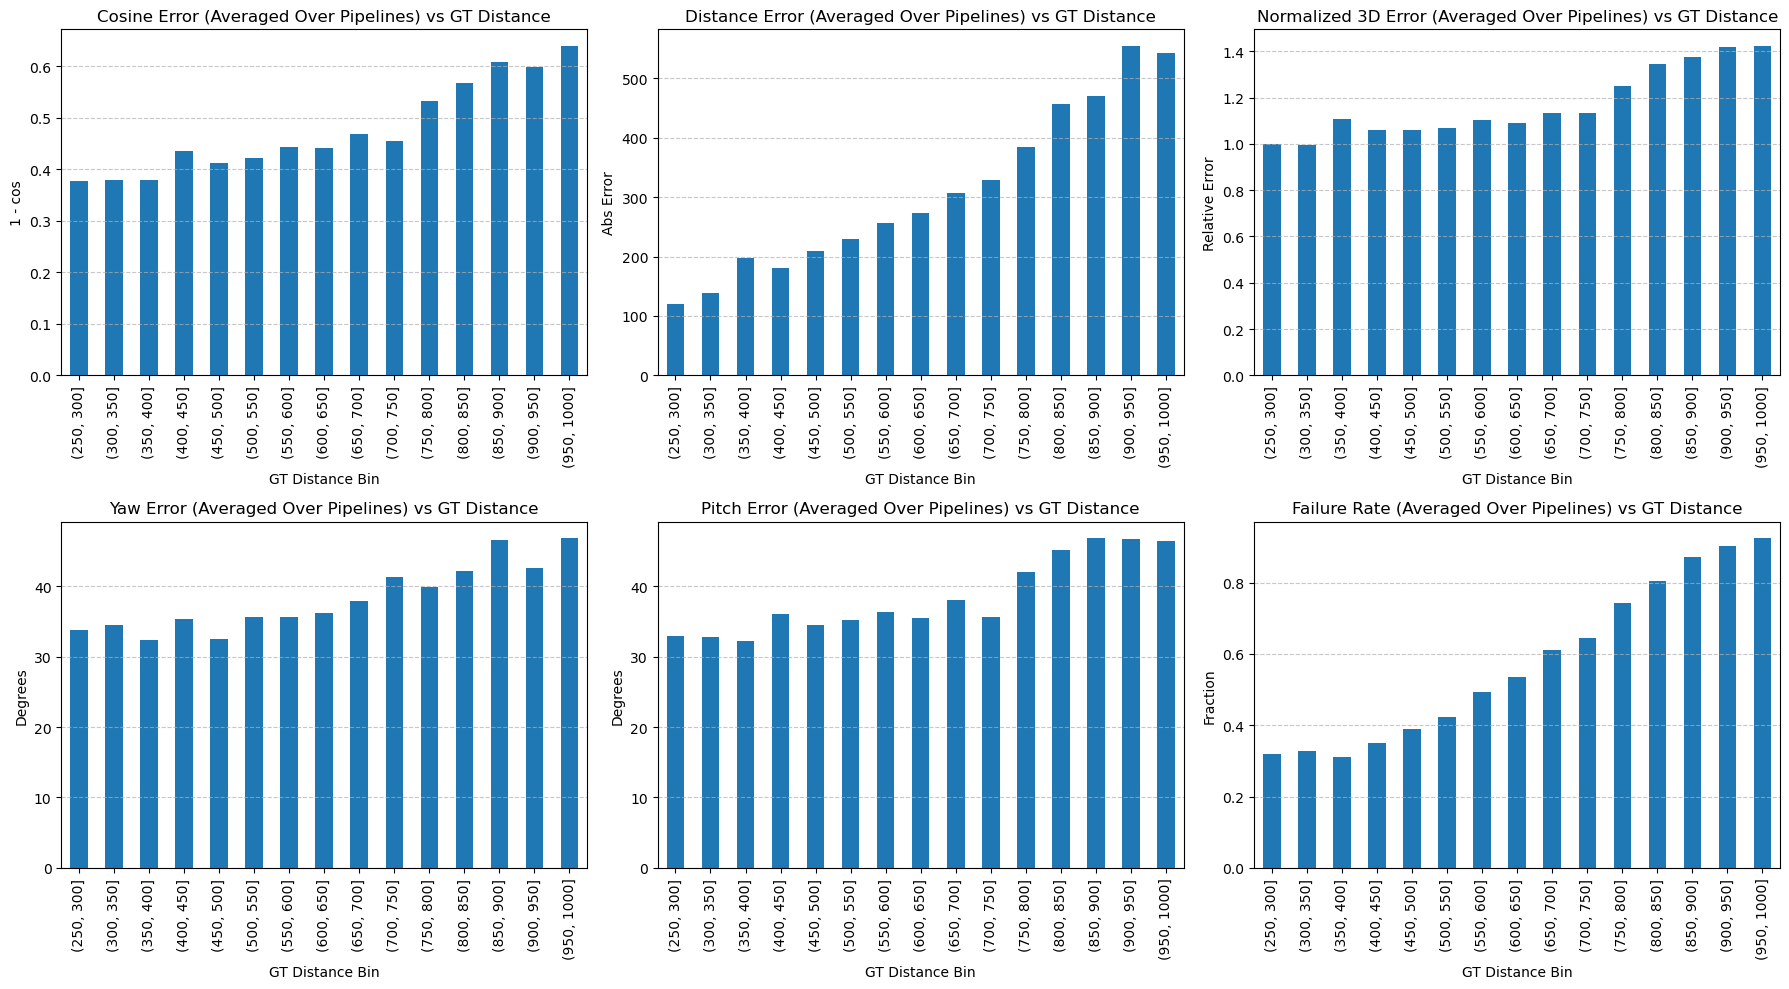

In [51]:
plot_binned_results(df, "dist")

C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_55852\1534718949.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {m: df.groupby(bin_col)[m].mean() for m in metrics}


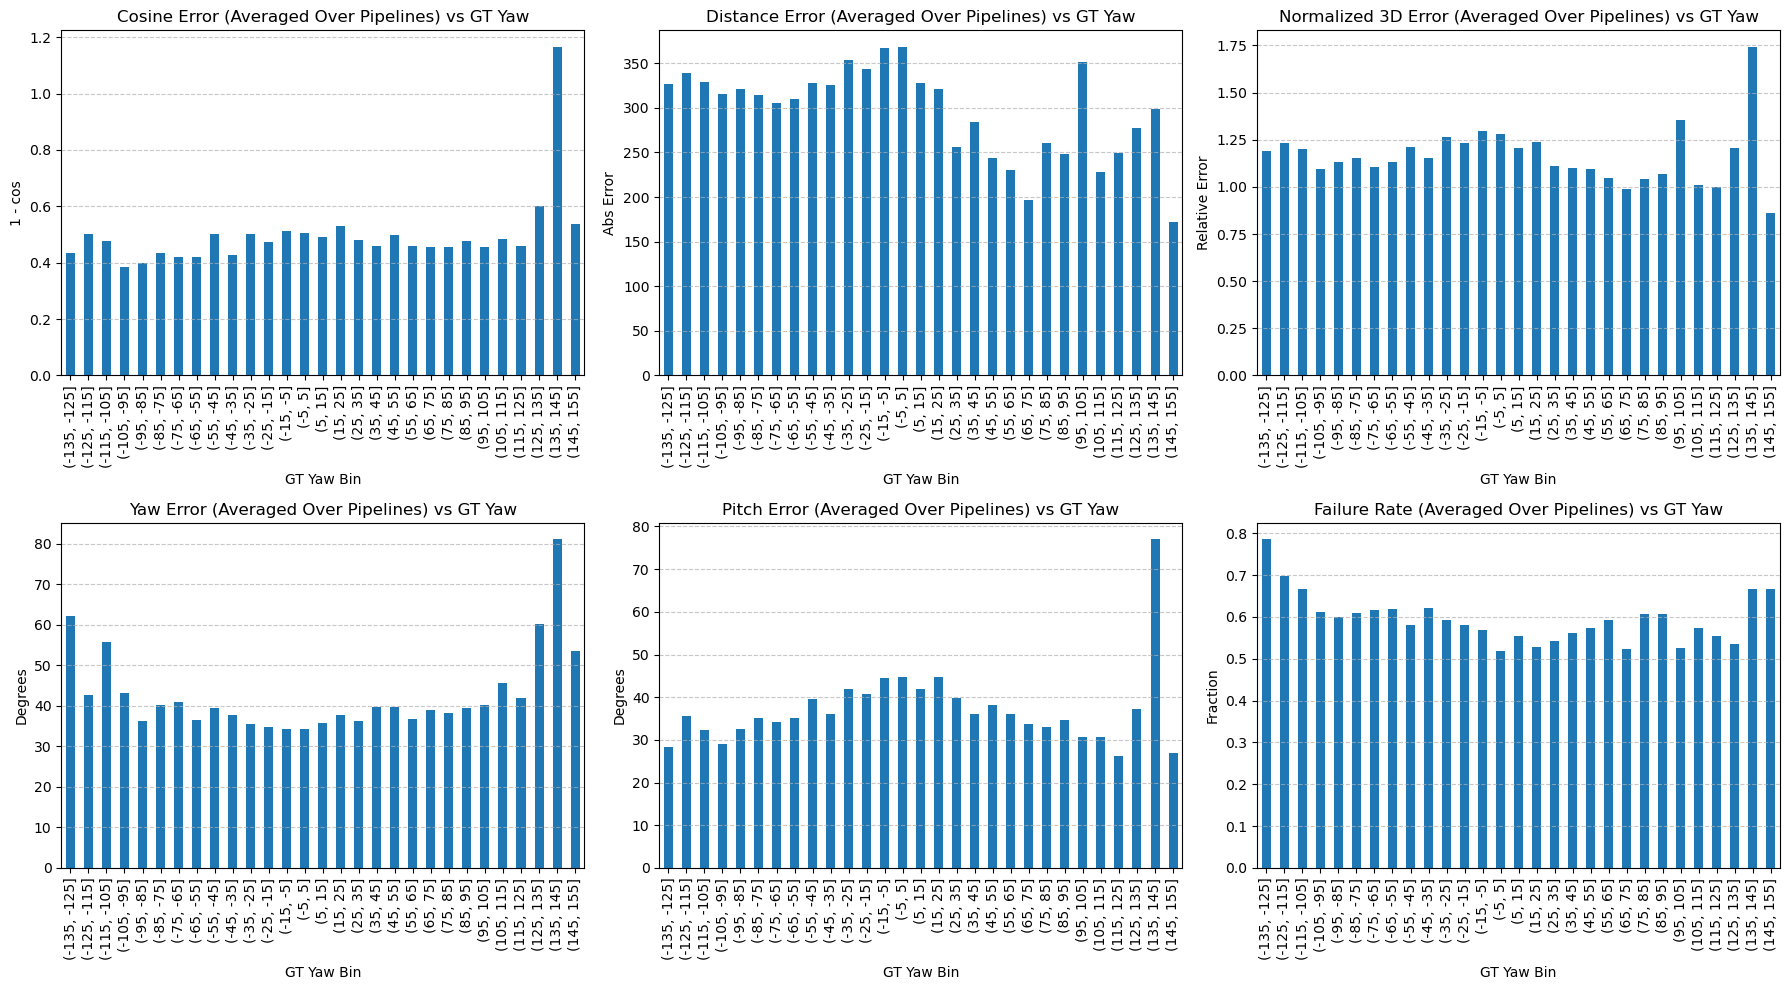

In [52]:
plot_binned_results(df, "yaw")

C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_55852\1534718949.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {m: df.groupby(bin_col)[m].mean() for m in metrics}


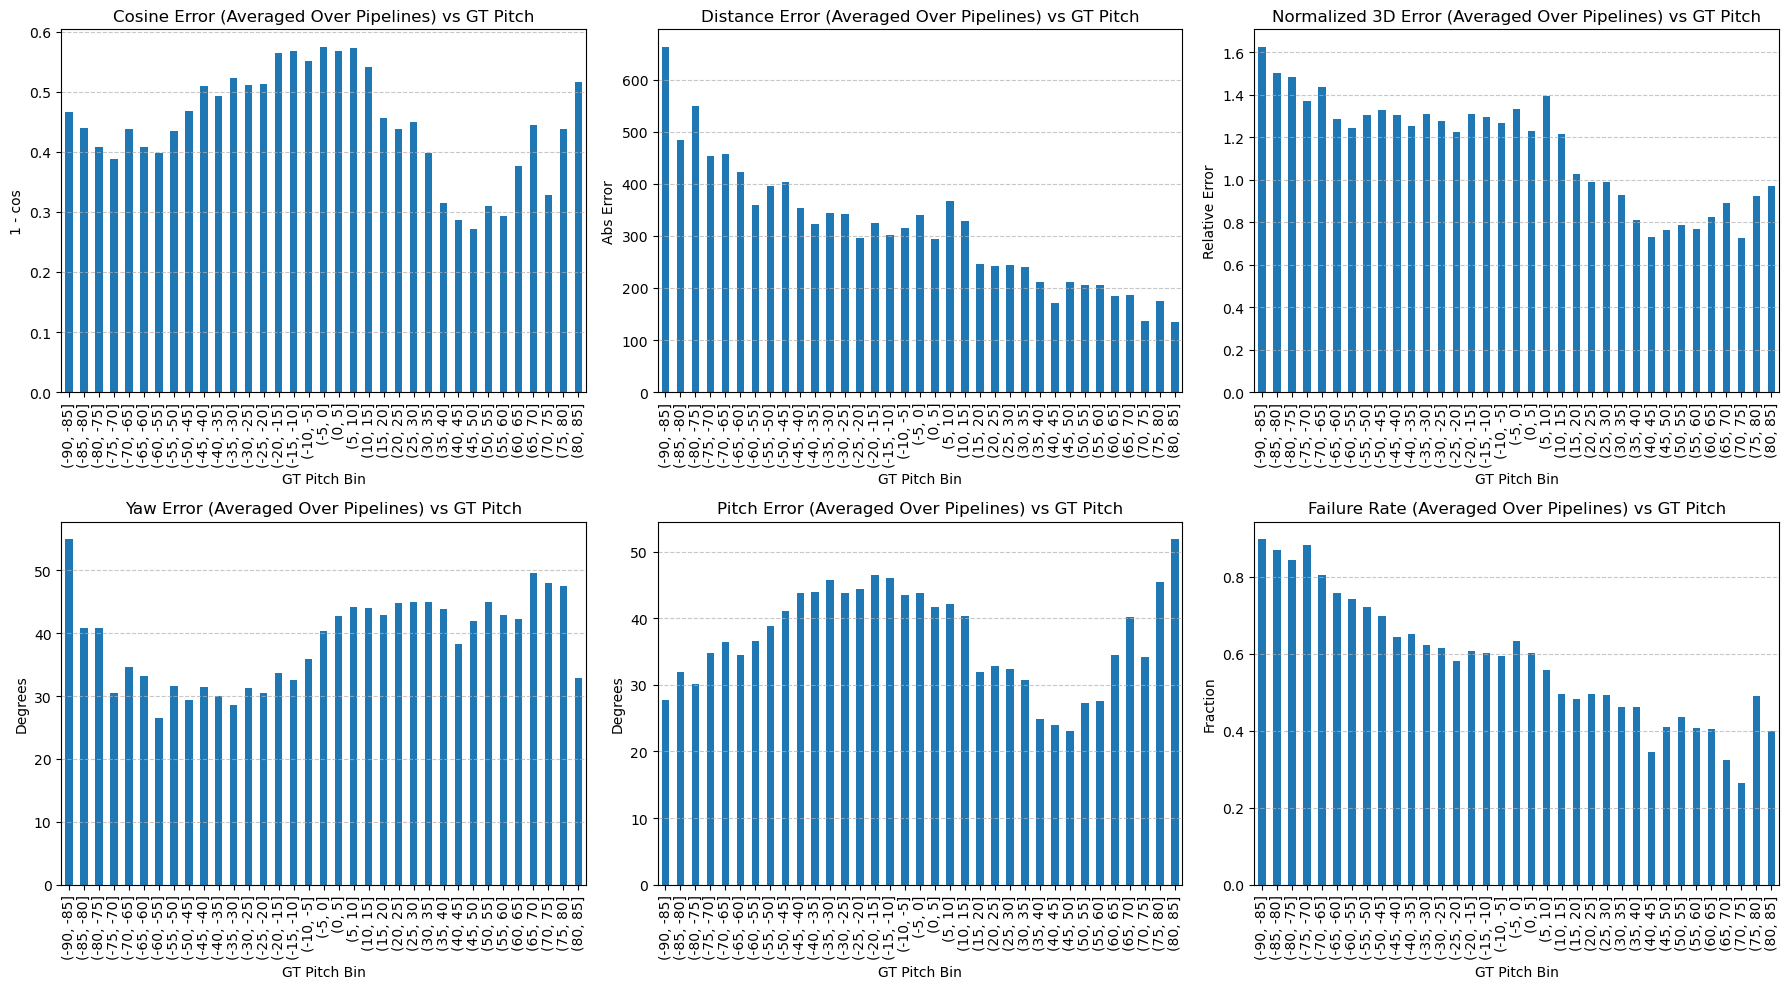

In [53]:
plot_binned_results(df, "pitch")

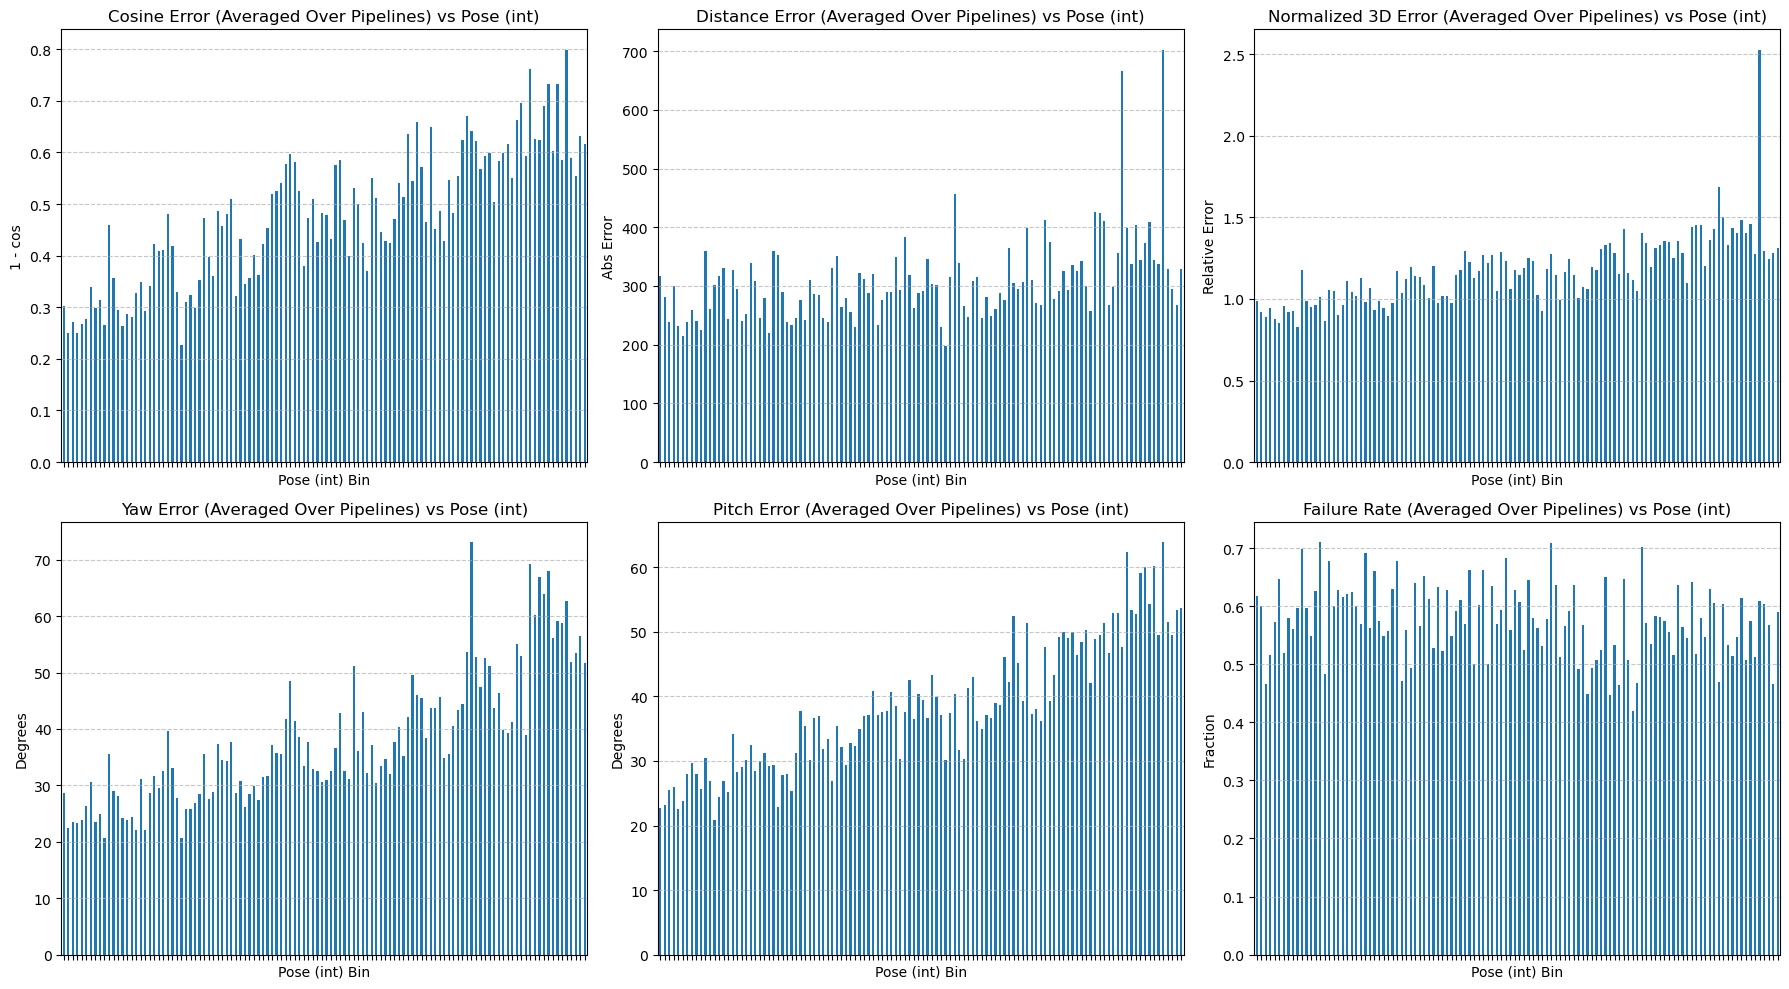

In [54]:
plot_binned_results(df, "pose")

C:\Users\ExoHorizon\AppData\Local\Temp\ipykernel_55852\1534718949.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return {m: df.groupby(bin_col)[m].mean() for m in metrics}


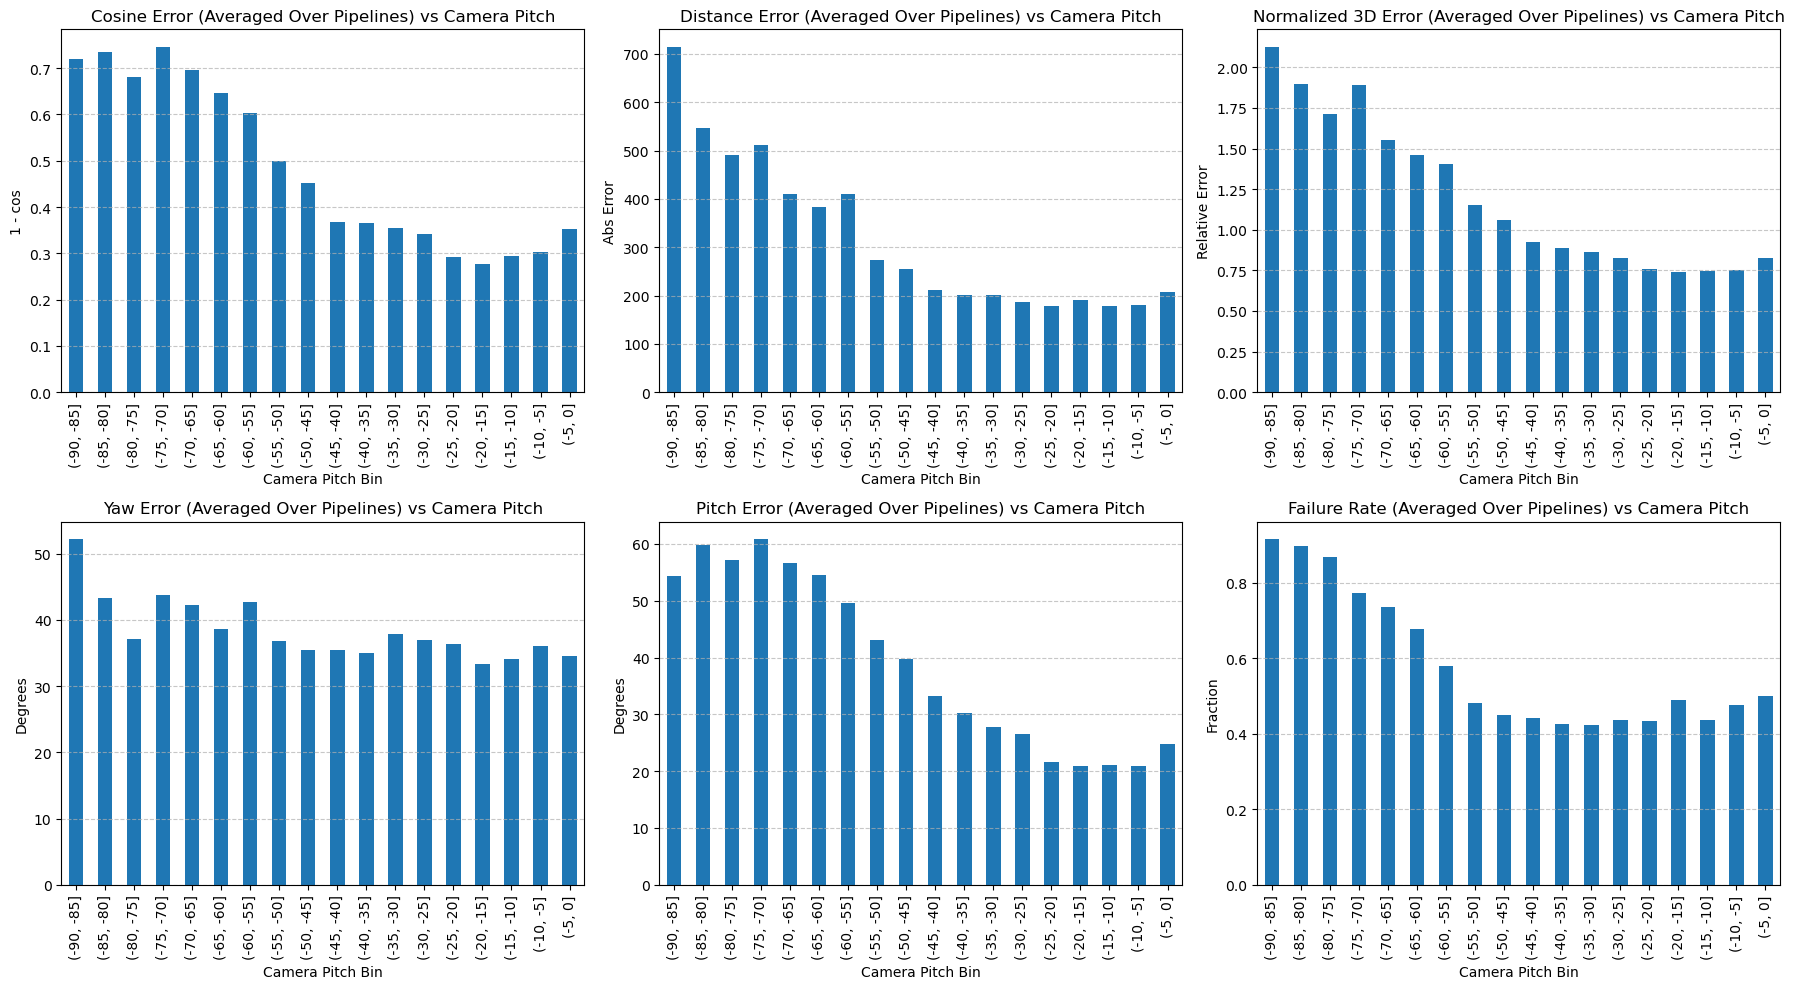

In [55]:
plot_binned_results(df, "cam_pitch")